In [1]:
import requests
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

def search_items(query, num=15):
    """Search the public ArcGIS Online item catalog."""
    r = requests.get("https://www.arcgis.com/sharing/rest/search",
                      params={"q": query, "f": "json", "num": num})
    r.raise_for_status()
    return r.json()

def get_item_url(item_id):
    """Resolve an ArcGIS item id to its live FeatureServer URL."""
    r = requests.get(f"https://www.arcgis.com/sharing/rest/content/items/{item_id}", params={"f": "json"})
    r.raise_for_status()
    return r.json().get("url")

def list_service_layers(feature_server_url):
    """Print the layers/tables available inside a FeatureServer."""
    r = requests.get(feature_server_url, params={"f": "json"})
    r.raise_for_status()
    data = r.json()
    print("LAYERS:")
    for l in data.get("layers", []):
        print(" ", l["id"], "-", l["name"])
    print("TABLES:")
    for t in data.get("tables", []):
        print(" ", t["id"], "-", t["name"])

def try_query(url, params):
    r = requests.get(url, params=params, timeout=15)
    try:
        return r.json()
    except ValueError:
        return {"error": {"message": "non-json response", "status": r.status_code}}

def get_polygon_geometry(feature_server_url, layer_id=0):
    """Fetch a single polygon feature's geometry (used for city boundaries)."""
    params = {"where": "1=1", "outFields": "*", "f": "json", "returnGeometry": "true"}
    data = try_query(feature_server_url.rstrip("/") + "/query", params)
    if "error" not in data and data.get("features"):
        return data["features"][0]["geometry"]
    data2 = try_query(feature_server_url.rstrip("/") + f"/{layer_id}/query", params)
    if "error" not in data2 and data2.get("features"):
        return data2["features"][0]["geometry"]
    return None

def query_all_features(feature_server_url, layer_id=0, where="1=1",
                        geometry=None, geometry_type=None, spatial_rel="esriSpatialRelIntersects",
                        out_fields="*", page_size=1000):
    """Paginated ArcGIS REST query. Uses POST so large polygon geometries don't hit URL-length limits."""
    query_url = feature_server_url.rstrip("/") + f"/{layer_id}/query"
    all_records = []
    offset = 0
    while True:
        params = {
            "where": where, "outFields": out_fields, "f": "json",
            "resultOffset": offset, "resultRecordCount": page_size,
            "returnGeometry": "false"
        }
        if geometry is not None:
            params["geometry"] = json.dumps(geometry)
            params["geometryType"] = geometry_type
            params["spatialRel"] = spatial_rel
            params["inSR"] = geometry.get("spatialReference", {}).get("wkid", 4326)
        r = requests.post(query_url, data=params, timeout=30)
        try:
            data = r.json()
        except ValueError:
            print(f"Non-JSON response at offset {offset}, status {r.status_code}")
            break
        if "error" in data:
            print("ERROR:", data["error"])
            break
        feats = data.get("features", [])
        if not feats:
            break
        all_records.extend([f["attributes"] for f in feats])
        if len(feats) < page_size:
            break
        offset += page_size
    return pd.DataFrame(all_records)


In [2]:
# Fulton County Board of Assessors — Tax Parcels 2025 (official CAMA data)
fulton_url = "https://services1.arcgis.com/AQDHTHDrZzfsFsB5/arcgis/rest/services/Tax_Parcels_2025/FeatureServer"

# City of Alpharetta's official boundary (used as a spatial filter against Fulton's parcels)
alpharetta_boundary_url = get_item_url("0604e2f1a09b49e2bffd8b4229a96d10")
alpharetta_geom = get_polygon_geometry(alpharetta_boundary_url)
alpharetta_geom["spatialReference"] = {"wkid": 2240}  # Georgia State Plane West, US feet

alpharetta_parcels = query_all_features(
    fulton_url, layer_id=0,
    geometry=alpharetta_geom, geometry_type="esriGeometryPolygon", spatial_rel="esriSpatialRelIntersects"
)
print("Alpharetta parcels:", len(alpharetta_parcels))
alpharetta_parcels.head()


Alpharetta parcels: 22904


,OBJECTID,ParcelID,TaxYear,Address,AddrNumber,AddrPreDir,AddrStreet,AddrSuffix,AddrPosDir,AddrUntTyp,...,LivUnits,LandAcres,NbrHood,Subdiv,SubdivNum,SubdivLot,SubdivBlck,FeatureID,Shape__Area,Shape__Length
0,8,22 434112460329,2025,900 COBBLESTON CT,900,None,COBBLESTON,CT,None,None,...,1.0,0.3241,22031,None,None,None,None,22 434112460329,15341.024414,507.399147
1,9,22 434112460337,2025,1475 SHADE TREE WAY,1475,None,SHADE TREE,WAY,None,None,...,1.0,0.3601,22031,None,None,None,None,22 434112460337,14381.416748,489.575744
2,10,22 434112460345,2025,1485 SHADE TREE WAY,1485,None,SHADE TREE,WAY,None,None,...,1.0,0.3405,22031,None,None,None,None,22 434112460345,14589.536621,513.390873
3,11,22 434112460352,2025,1495 SHADE TREE WAY,1495,None,SHADE TREE,WAY,None,None,...,1.0,0.3411,22031,None,None,None,None,22 434112460352,15922.949463,537.054112
4,12,22 434112460436,2025,1530 SHADE TREE WAY,1530,None,SHADE TREE,WAY,None,None,...,1.0,0.4058,22031,None,None,None,None,22 434112460436,17854.407959,556.900499


In [3]:
forsyth_url = get_item_url("a57125fcac534eb58c1d63325894e6e8")

cumming_parcels = query_all_features(forsyth_url, layer_id=0, where="PSTLCITY = 'CUMMING'")
print("Cumming parcels:", len(cumming_parcels))
cumming_parcels.head()


Cumming parcels: 66779


,OBJECTID,PARCELID,BUILDING,USECD,USEDSCRP,NGHBRHDCD,CLASSCD,CLASSDSCRP,SITEADDRESS,CNVYNAME,...,TXBLVALYRCHG,TXBLPCNTCHG,STATEDAREA,ZONING,TAXYEAR,Shape__Area,Shape__Length,GlobalID,Link,TaxBillLink
0,109,184 341,None,0100,SF RESIDENTIAL,02044,R3,Residential 1-5 acres,8905 FRIARBRIDGE DR,Shakerag Farms,...,76896.0,50.59,0.18,PUD,2025,8004.695097,418.656032,{E5497CA3-3C54-427F-8090-99E0EBAEAAA5},https://qpublic.schneidercorp.com/Application....,https://forsythproperty.assurancegov.com/Prope...
1,119,184 312,None,0100,SF RESIDENTIAL,02044,R3,Residential 1-5 acres,8315 FRIARBRIDGE DR,Shakerag Farms,...,28432.0,12.05,0.22,PUD,2025,7701.167607,360.324569,{4E122985-DDB8-49DE-B992-946880052209},https://qpublic.schneidercorp.com/Application....,https://forsythproperty.assurancegov.com/Prope...
2,204,184 001,None,0120,"RURAL AC , 0 - 5 AC",02000,R3,Residential 1-5 acres,1031 BOYD RD,None,...,11728.0,9.08,1.97,A1,2025,91142.715644,1247.839029,{E16D4E6A-B10F-4E3E-96BC-E745235981B7},https://qpublic.schneidercorp.com/Application....,https://forsythproperty.assurancegov.com/Prope...
3,215,184 443,None,0116,CELL TOWER,C2094,C3,Commercial 1-5 acres,6431 OLD ATLANTA RD,None,...,25240.0,61.49,0.13,CBD,2025,5686.728269,499.472504,{4F4F0A2F-CBC6-4311-8C2B-FF01F676A0C4},https://qpublic.schneidercorp.com/Application....,https://forsythproperty.assurancegov.com/Prope...
4,241,184 444,None,0116,CELL TOWER,C2094,C3,Commercial 1-5 acres,6421 OLD ATLANTA RD,None,...,29700.0,150.00,0.09,CBD,2025,3313.349667,296.225375,{7B43F64E-E280-4B44-B18B-4BF18B371C80},https://qpublic.schneidercorp.com/Application....,https://forsythproperty.assurancegov.com/Prope...


In [4]:
print(alpharetta_parcels['LUCode'].value_counts().head(15))
print()
print(cumming_parcels[['USECD', 'USEDSCRP']].value_counts().head(15))


LUCode
101    15046
107     2914
106     1589
355      879
100      490
300      285
111      195
188      140
600      101
301       67
374       65
3B3       59
699       56
3A4       50
373       45
Name: count, dtype: int64

USECD  USEDSCRP                      
0100   SF RESIDENTIAL                    47764
0120   RURAL AC , 0 - 5 AC                4492
0309   TOWNHOME                           2994
0150   RURAL ZONE RESIDENTIAL             2160
0122   SFR WATER                          1553
0300   RESIDENTIAL CONDOMINIUM            1464
0130   RURAL ACS , 5.01 - 25 AC           1110
0700   COMMERCIAL                          662
0123   SFR GOLF                            598
0424   OFFICE CONDO                        336
0101   SFR CREEK                           305
0127   SFR P LAKE                          295
0124   SFR NODOCK                          275
0600   INDUSTRIAL                          259
0140   RURAL ACL , GREATER THAN 25 AC      183
Name: count, dtype: int64


In [5]:
# Fulton: 101 = Single Family, 106 = SF Residential Condo, 107 = SF Residential Townhouse
fulton_residential_codes = ['101', '106', '107']
alpharetta_clean = alpharetta_parcels[alpharetta_parcels['LUCode'].isin(fulton_residential_codes)].copy()
print(f"Alpharetta: {len(alpharetta_parcels)} -> {len(alpharetta_clean)} after residential filter")
print(alpharetta_clean['LUCode'].value_counts())


Alpharetta: 22904 -> 19549 after residential filter
LUCode
101    15046
107     2914
106     1589
Name: count, dtype: int64


In [6]:
# Forsyth: USECD codes representing an actual SF/condo/townhome dwelling
forsyth_residential_codes = [
    '0100',  # SF RESIDENTIAL
    '0101',  # SFR CREEK
    '0113',  # SFR RIVER
    '0122',  # SFR WATER
    '0123',  # SFR GOLF
    '0124',  # SFR NODOCK
    '0127',  # SFR P LAKE
    '0300',  # RESIDENTIAL CONDOMINIUM
    '0309',  # TOWNHOME
]
cumming_clean = cumming_parcels[cumming_parcels['USECD'].isin(forsyth_residential_codes)].copy()

# Safety net: require an actual structure, in case a vacant lot slipped in under a residential code
cumming_clean = cumming_clean[cumming_clean['BLDGAREA'].fillna(0) > 0]

print(f"Cumming: {len(cumming_parcels)} -> {len(cumming_clean)} after residential filter")
print(cumming_clean['USEDSCRP'].value_counts())


Cumming: 66779 -> 53980 after residential filter
USEDSCRP
SF RESIDENTIAL             46705
TOWNHOME                    2946
SFR WATER                   1464
RESIDENTIAL CONDOMINIUM     1423
SFR GOLF                     596
SFR CREEK                    303
SFR P LAKE                   293
SFR NODOCK                   223
SFR RIVER                     27
Name: count, dtype: int64


In [7]:
print("=== ALPHARETTA: potential data issues ===")
print("ImprAppr == 0:", (alpharetta_clean['ImprAppr'] == 0).sum())
print("LivUnits == 0:", (alpharetta_clean['LivUnits'] == 0).sum())
print("TotAppr < 50000:", (alpharetta_clean['TotAppr'] < 50000).sum())


=== ALPHARETTA: potential data issues ===
ImprAppr == 0: 19
LivUnits == 0: 209
TotAppr < 50000: 4


In [8]:
print("=== CUMMING: potential data issues ===")
print("RESFLRAREA == 0 (but BLDGAREA > 0):", ((cumming_clean['RESFLRAREA'] == 0) & (cumming_clean['BLDGAREA'] > 0)).sum())
print("STATEDAREA == 0, broken out by USEDSCRP:")
print(cumming_clean[cumming_clean['STATEDAREA'] == 0]['USEDSCRP'].value_counts())


=== CUMMING: potential data issues ===
RESFLRAREA == 0 (but BLDGAREA > 0): 1
STATEDAREA == 0, broken out by USEDSCRP:
USEDSCRP
RESIDENTIAL CONDOMINIUM    1179
TOWNHOME                     25
SFR NODOCK                   15
SF RESIDENTIAL                2
Name: count, dtype: int64


In [9]:
# --- Alpharetta: drop rows with no recorded improvement value or no living unit ---
before = len(alpharetta_clean)
alpharetta_final = alpharetta_clean[
    (alpharetta_clean['ImprAppr'] > 0) &
    (alpharetta_clean['LivUnits'] > 0) &
    (alpharetta_clean['TotAppr'] >= 50000)
].copy()
print(f"Alpharetta: {before} -> {len(alpharetta_final)} after dropping incomplete records")


Alpharetta: 19549 -> 19228 after dropping incomplete records


In [10]:
# --- Cumming: drop the one row with missing floor area; keep condo/townhome 0-land-area rows as legitimate ---
before = len(cumming_clean)
cumming_final = cumming_clean[
    ~((cumming_clean['RESFLRAREA'] == 0) & (cumming_clean['BLDGAREA'] > 0))
].copy()

# Encode "owns own lot" as a real feature rather than treating 0 land area as missing
cumming_final['owns_lot'] = (cumming_final['STATEDAREA'] > 0).astype(int)

print(f"Cumming: {before} -> {len(cumming_final)} after cleaning")
print(cumming_final['owns_lot'].value_counts())


Cumming: 53980 -> 53979 after cleaning
owns_lot
1    52706
0     1273
Name: count, dtype: int64


In [11]:
save_dir = 'data'
os.makedirs(save_dir, exist_ok=True)

alpharetta_final.to_csv(f'{save_dir}/alpharetta_clean.csv', index=False)
cumming_final.to_csv(f'{save_dir}/cumming_clean.csv', index=False)

print("Saved:")
print(f" - alpharetta_clean.csv: {len(alpharetta_final)} rows, {alpharetta_final.shape[1]} cols")
print(f" - cumming_clean.csv: {len(cumming_final)} rows, {cumming_final.shape[1]} cols")


Saved:
 - alpharetta_clean.csv: 19228 rows, 34 cols
 - cumming_clean.csv: 53979 rows, 40 cols


In [12]:
alpharetta_final['market_value'] = alpharetta_final['TotAppr']
cumming_final['market_value'] = cumming_final['CNTASSDVAL']  # already market value, not 40%-assessed

cumming_final['home_age'] = 2026 - cumming_final['RESYRBLT']
cumming_final['value_per_sqft'] = cumming_final['market_value'] / cumming_final['BLDGAREA']
alpharetta_final['value_per_acre'] = alpharetta_final['market_value'] / alpharetta_final['LandAcres']

print("Alpharetta average market value:", f"${alpharetta_final['market_value'].mean():,.0f}")
print("Cumming average market value:", f"${cumming_final['market_value'].mean():,.0f}")


Alpharetta average market value: $643,296
Cumming average market value: $645,612


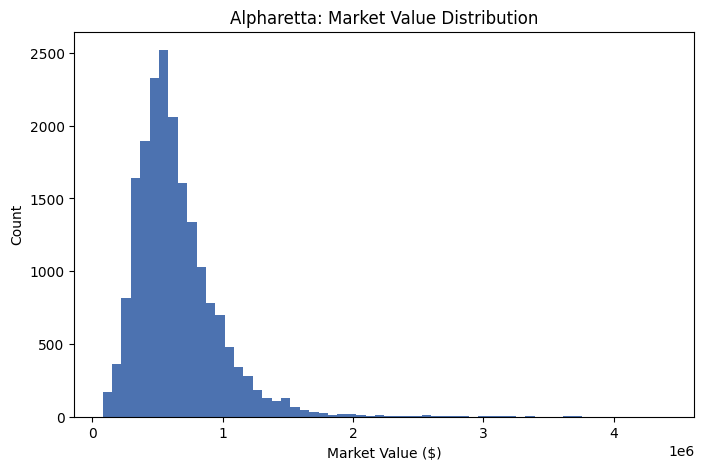

In [13]:
# Alpharetta: Market Value Distribution
plt.figure(figsize=(8, 5))
plt.hist(alpharetta_final['market_value'], bins=60, color='#4C72B0')
plt.title('Alpharetta: Market Value Distribution')
plt.xlabel('Market Value ($)')
plt.ylabel('Count')
plt.show()


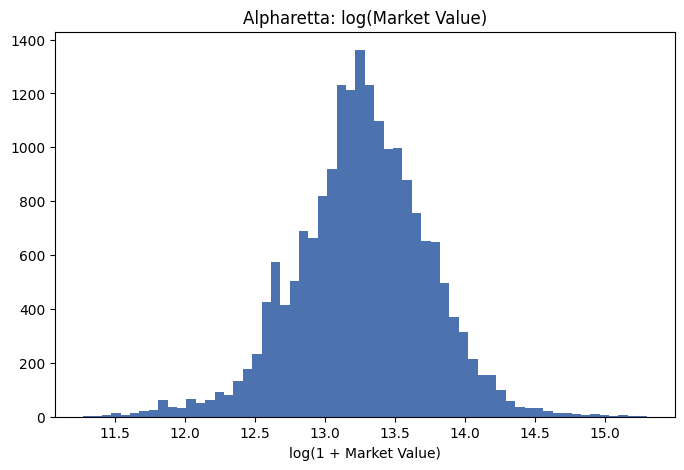

In [14]:
# Alpharetta: log(Market Value)
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(alpharetta_final['market_value']), bins=60, color='#4C72B0')
plt.title('Alpharetta: log(Market Value)')
plt.xlabel('log(1 + Market Value)')
plt.show()


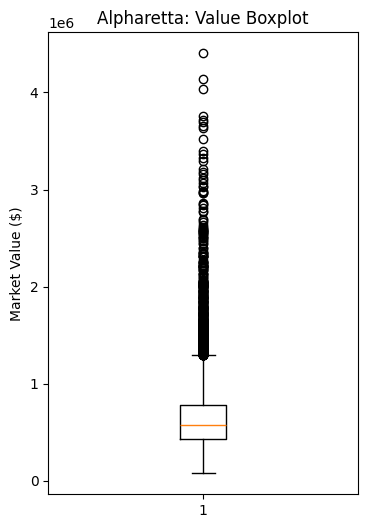

In [15]:
# Alpharetta: Value Boxplot
plt.figure(figsize=(4, 6))
plt.boxplot(alpharetta_final['market_value'], vert=True)
plt.title('Alpharetta: Value Boxplot')
plt.ylabel('Market Value ($)')
plt.show()


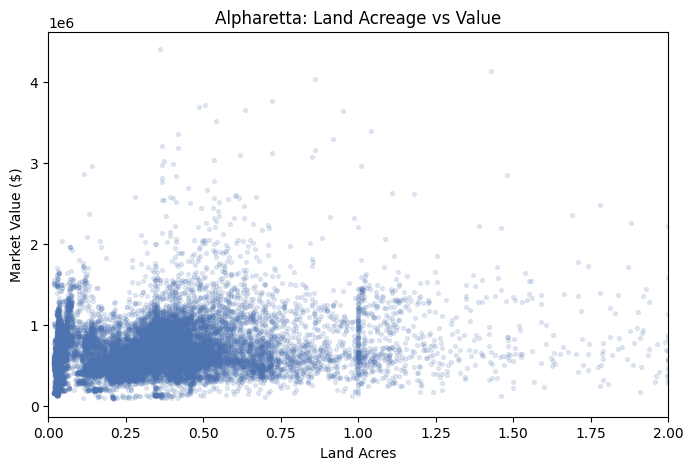

In [16]:
# Alpharetta: Acreage vs Value
plt.figure(figsize=(8, 5))
plt.scatter(alpharetta_final['LandAcres'], alpharetta_final['market_value'], alpha=0.15, s=8, color='#4C72B0')
plt.title('Alpharetta: Land Acreage vs Value')
plt.xlabel('Land Acres')
plt.ylabel('Market Value ($)')
plt.xlim(0, 2)
plt.show()


<Figure size 800x500 with 0 Axes>

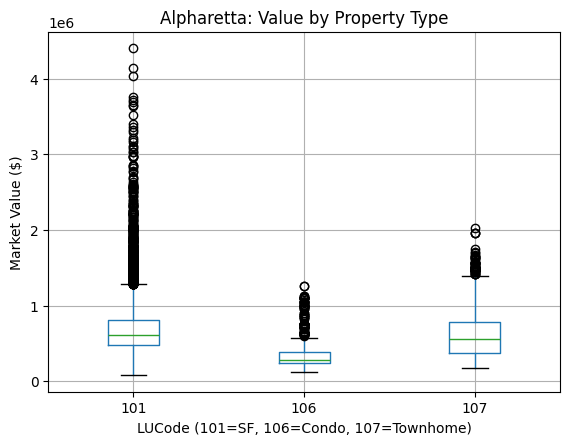

In [17]:
# Alpharetta: Value by Property Type
plt.figure(figsize=(8, 5))
alpharetta_final.boxplot(column='market_value', by='LUCode')
plt.title('Alpharetta: Value by Property Type')
plt.suptitle('')
plt.xlabel('LUCode (101=SF, 106=Condo, 107=Townhome)')
plt.ylabel('Market Value ($)')
plt.show()


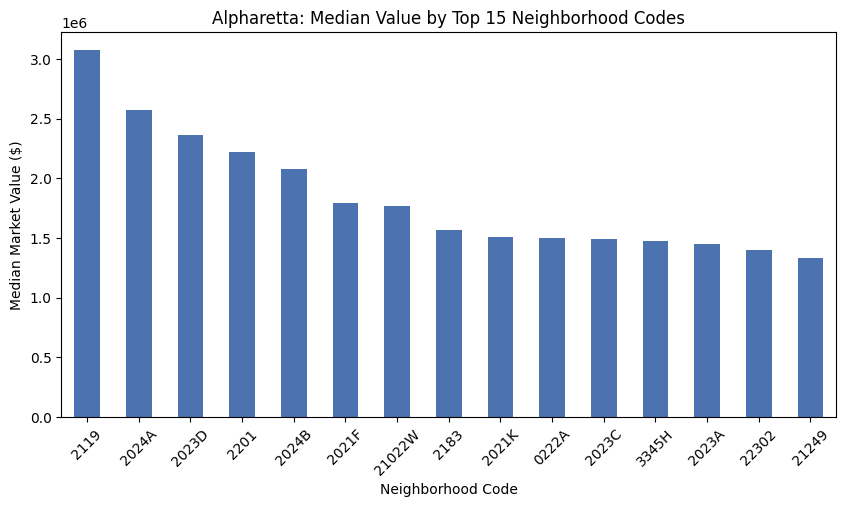

In [18]:
# Alpharetta: Median Value by Top 15 Neighborhoods
top_nbrhoods = alpharetta_final.groupby('NbrHood')['market_value'].median().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 5))
top_nbrhoods.plot(kind='bar', color='#4C72B0')
plt.title('Alpharetta: Median Value by Top 15 Neighborhood Codes')
plt.xlabel('Neighborhood Code')
plt.ylabel('Median Market Value ($)')
plt.xticks(rotation=45)
plt.show()


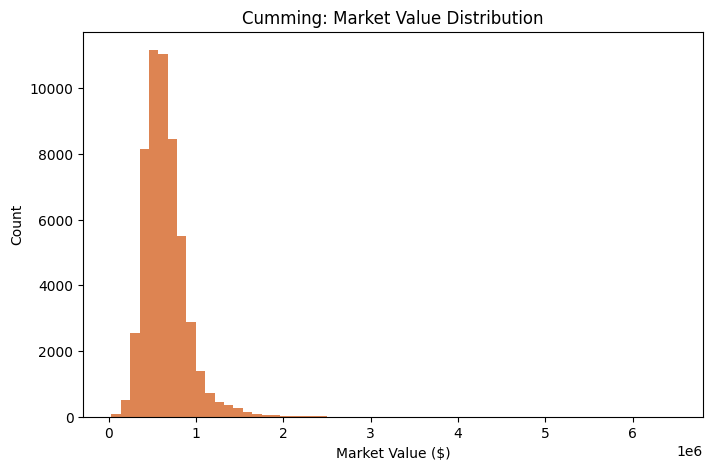

In [19]:
# Cumming: Market Value Distribution
plt.figure(figsize=(8, 5))
plt.hist(cumming_final['market_value'], bins=60, color='#DD8452')
plt.title('Cumming: Market Value Distribution')
plt.xlabel('Market Value ($)')
plt.ylabel('Count')
plt.show()


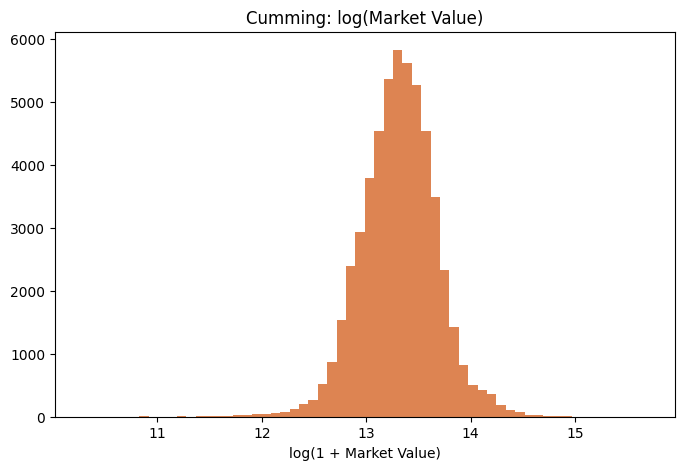

In [20]:
# Cumming: log(Market Value)
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(cumming_final['market_value']), bins=60, color='#DD8452')
plt.title('Cumming: log(Market Value)')
plt.xlabel('log(1 + Market Value)')
plt.show()


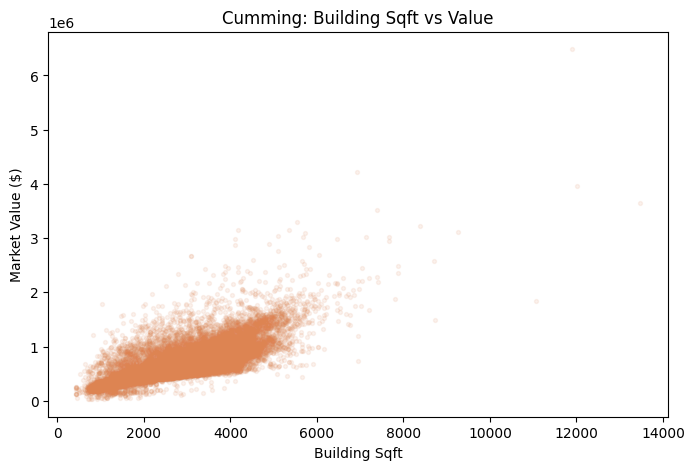

In [21]:
# Cumming: Building Sqft vs Value
plt.figure(figsize=(8, 5))
plt.scatter(cumming_final['BLDGAREA'], cumming_final['market_value'], alpha=0.1, s=8, color='#DD8452')
plt.title('Cumming: Building Sqft vs Value')
plt.xlabel('Building Sqft')
plt.ylabel('Market Value ($)')
plt.show()


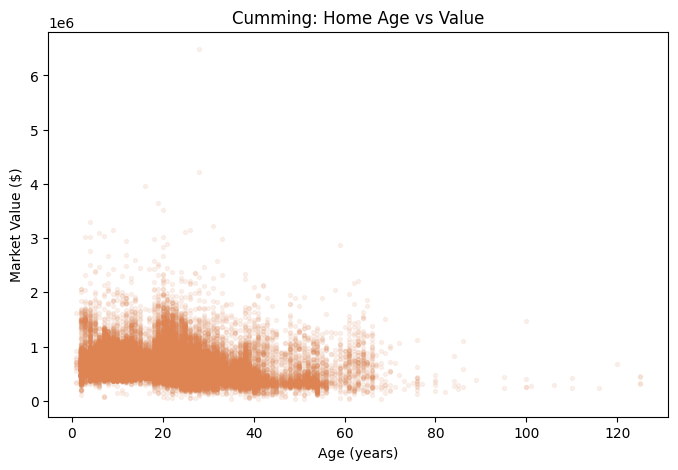

In [22]:
# Cumming: Home Age vs Value
plt.figure(figsize=(8, 5))
plt.scatter(cumming_final['home_age'], cumming_final['market_value'], alpha=0.1, s=8, color='#DD8452')
plt.title('Cumming: Home Age vs Value')
plt.xlabel('Age (years)')
plt.ylabel('Market Value ($)')
plt.show()


<Figure size 600x500 with 0 Axes>

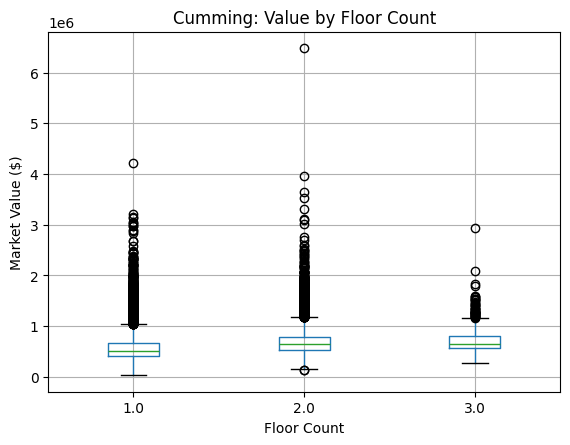

In [23]:
# Cumming: Value by Floor Count
plt.figure(figsize=(6, 5))
cumming_final.boxplot(column='market_value', by='FLOORCOUNT')
plt.title('Cumming: Value by Floor Count')
plt.suptitle('')
plt.xlabel('Floor Count')
plt.ylabel('Market Value ($)')
plt.show()


<Figure size 600x500 with 0 Axes>

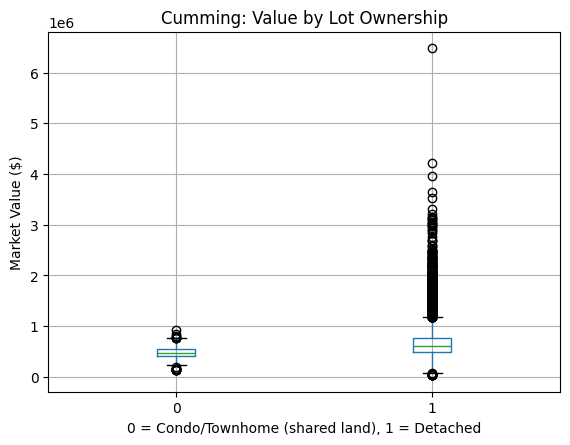

In [24]:
# Cumming: Value by Lot Ownership
plt.figure(figsize=(6, 5))
cumming_final.boxplot(column='market_value', by='owns_lot')
plt.title('Cumming: Value by Lot Ownership')
plt.suptitle('')
plt.xlabel('0 = Condo/Townhome (shared land), 1 = Detached')
plt.ylabel('Market Value ($)')
plt.show()


<Figure size 1200x500 with 0 Axes>

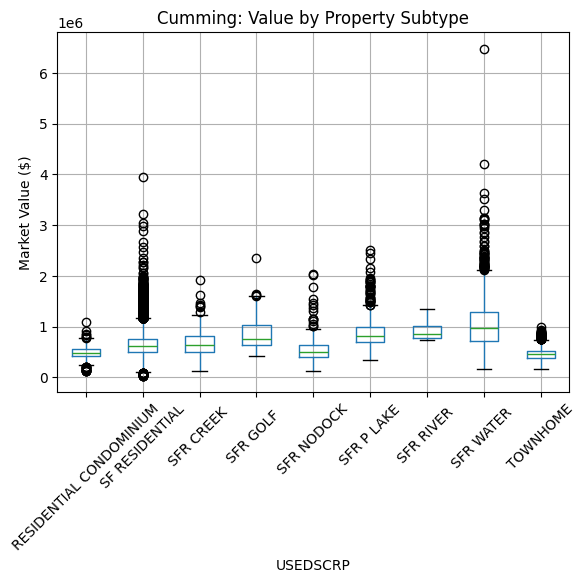

In [25]:
# Cumming: Value by Property Subtype
plt.figure(figsize=(12, 5))
cumming_final.boxplot(column='market_value', by='USEDSCRP', rot=45)
plt.title('Cumming: Value by Property Subtype')
plt.suptitle('')
plt.ylabel('Market Value ($)')
plt.show()


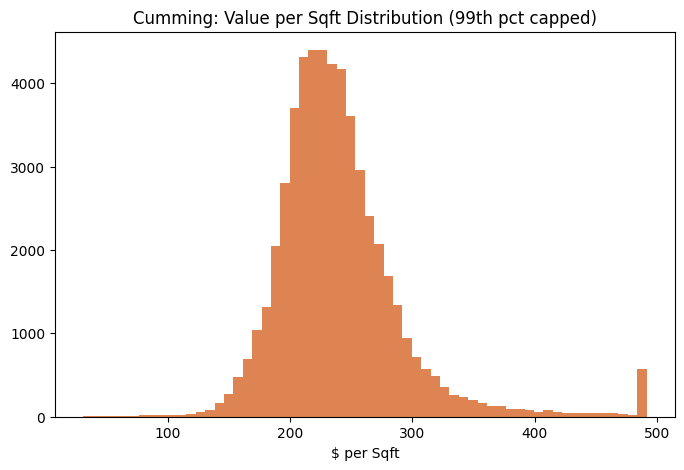

In [26]:
# Cumming: Value per Sqft Distribution
plt.figure(figsize=(8, 5))
plt.hist(cumming_final['value_per_sqft'].clip(upper=cumming_final['value_per_sqft'].quantile(0.99)), bins=60, color='#DD8452')
plt.title('Cumming: Value per Sqft Distribution (99th pct capped)')
plt.xlabel('$ per Sqft')
plt.show()


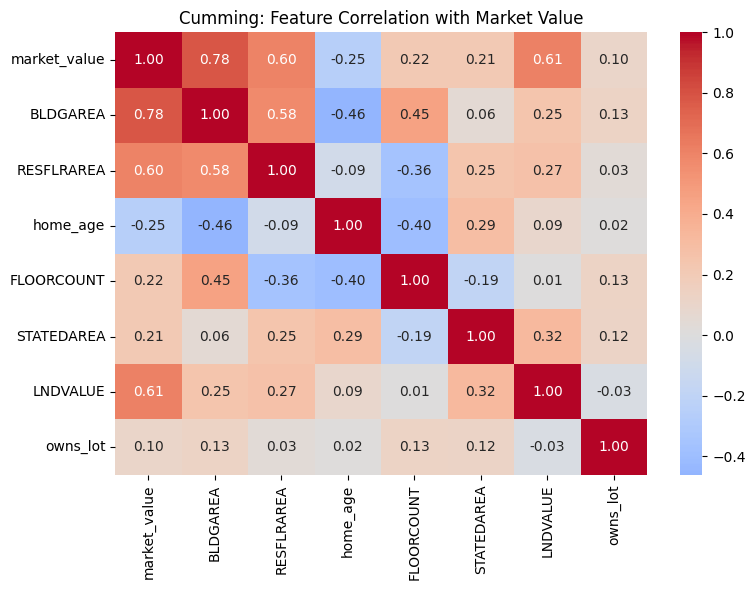

In [27]:
# Cumming: Feature Correlation Heatmap
numeric_cols = ['market_value', 'BLDGAREA', 'RESFLRAREA', 'home_age', 'FLOORCOUNT', 'STATEDAREA', 'LNDVALUE', 'owns_lot']
plt.figure(figsize=(8, 6))
sns.heatmap(cumming_final[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Cumming: Feature Correlation with Market Value')
plt.tight_layout()
plt.show()


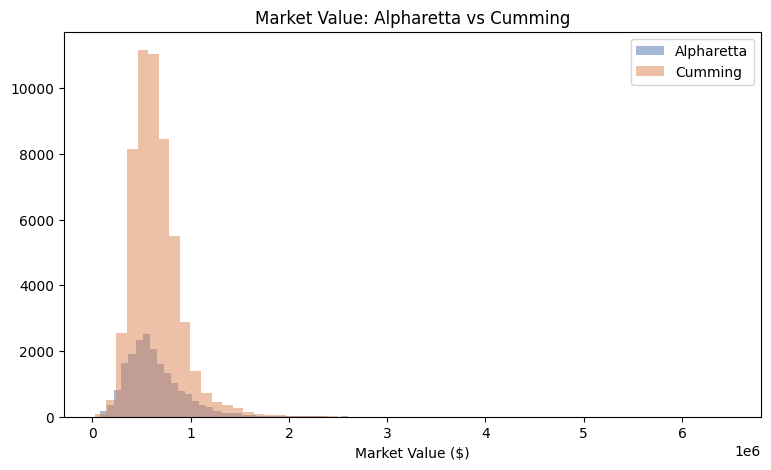

In [28]:
# Side-by-side: Alpharetta vs Cumming
plt.figure(figsize=(9, 5))
plt.hist(alpharetta_final['market_value'], bins=60, alpha=0.5, label='Alpharetta', color='#4C72B0')
plt.hist(cumming_final['market_value'], bins=60, alpha=0.5, label='Cumming', color='#DD8452')
plt.title('Market Value: Alpharetta vs Cumming')
plt.xlabel('Market Value ($)')
plt.legend()
plt.show()


In [29]:
!pip install lightgbm optuna shap --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 22.2 MB/s eta 0:00:00


In [30]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
import optuna
import shap
import joblib

cat_features_cumming = ['USECD', 'NGHBRHDCD', 'CLASSCD', 'ZONING']
for col in cat_features_cumming:
    cumming_final[col] = cumming_final[col].astype('category')

feature_cols_cumming = ['BLDGAREA', 'RESFLRAREA', 'home_age', 'FLOORCOUNT',
                         'STATEDAREA', 'LNDVALUE', 'owns_lot'] + cat_features_cumming

X = cumming_final[feature_cols_cumming]
y = np.log1p(cumming_final['market_value'])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f"Train: {X_train.shape}, Validation: {X_valid.shape}, Test: {X_test.shape}")


Train: (37785, 11), Validation: (8097, 11), Test: (8097, 11)


In [31]:
baseline_model = lgb.LGBMRegressor(random_state=42, verbose=-1)
baseline_model.fit(X_train, y_train, categorical_feature=cat_features_cumming)

pred_log = baseline_model.predict(X_test)
pred = np.expm1(pred_log)
actual = np.expm1(y_test)

rmse = root_mean_squared_error(actual, pred)
mae = mean_absolute_error(actual, pred)
r2 = r2_score(actual, pred)
print(f"Cumming Baseline — RMSE: ${rmse:,.0f}  MAE: ${mae:,.0f}  R2: {r2:.4f}")


Cumming Baseline — RMSE: $70,441  MAE: $42,399  R2: 0.9207


In [32]:
def objective(trial):
    params = {
        'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'n_estimators': 500,
    }
    model = lgb.LGBMRegressor(**params, random_state=42)
    model.fit(X_train, y_train, categorical_feature=cat_features_cumming)
    pred = model.predict(X_valid)  # validation, not test
    return root_mean_squared_error(y_valid, pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)
print("Best params:", study.best_params)


[I 2026-07-15 00:18:01,912] A new study created in memory with name: no-name-b1df397b-c646-4bad-9c2a-a83f35b16423


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-15 00:18:17,853] Trial 0 finished with value: 0.10157459763326299 and parameters: {'num_leaves': 117, 'learning_rate': 0.2415653931176456, 'feature_fraction': 0.8435017033693201, 'bagging_fraction': 0.9767706171705233, 'bagging_freq': 1, 'min_child_samples': 62}. Best is trial 0 with value: 0.10157459763326299.
[I 2026-07-15 00:18:32,262] Trial 1 finished with value: 0.09742262085578135 and parameters: {'num_leaves': 70, 'learning_rate': 0.02025662587951967, 'feature_fraction': 0.8718831278085104, 'bagging_fraction': 0.6921785514800118, 'bagging_freq': 5, 'min_child_samples': 83}. Best is trial 1 with value: 0.09742262085578135.
[I 2026-07-15 00:18:40,076] Trial 2 finished with value: 0.09789233970947463 and parameters: {'num_leaves': 95, 'learning_rate': 0.016402814245747112, 'feature_fraction': 0.6551654145300965, 'bagging_fraction': 0.5723687458761242, 'bagging_freq': 3, 'min_child_samples': 87}. Best is trial 1 with value: 0.09742262085578135.
[I 2026-07-15 00:18:48,513]

In [33]:
final_model_cumming = lgb.LGBMRegressor(**study.best_params, n_estimators=500, random_state=42, verbose=-1)
final_model_cumming.fit(X_train, y_train, categorical_feature=cat_features_cumming)

pred_log = final_model_cumming.predict(X_test)  # test set, never touched by tuning
pred = np.expm1(pred_log)
actual = np.expm1(y_test)

rmse = root_mean_squared_error(actual, pred)
mae = mean_absolute_error(actual, pred)
r2 = r2_score(actual, pred)
mape = np.mean(np.abs((actual - pred) / actual)) * 100
print(f"Cumming Tuned Model — RMSE: ${rmse:,.0f}  MAE: ${mae:,.0f}  R2: {r2:.4f}  MAPE: {mape:.2f}%")


Cumming Tuned Model — RMSE: $69,578  MAE: $41,690  R2: 0.9226  MAPE: 6.42%


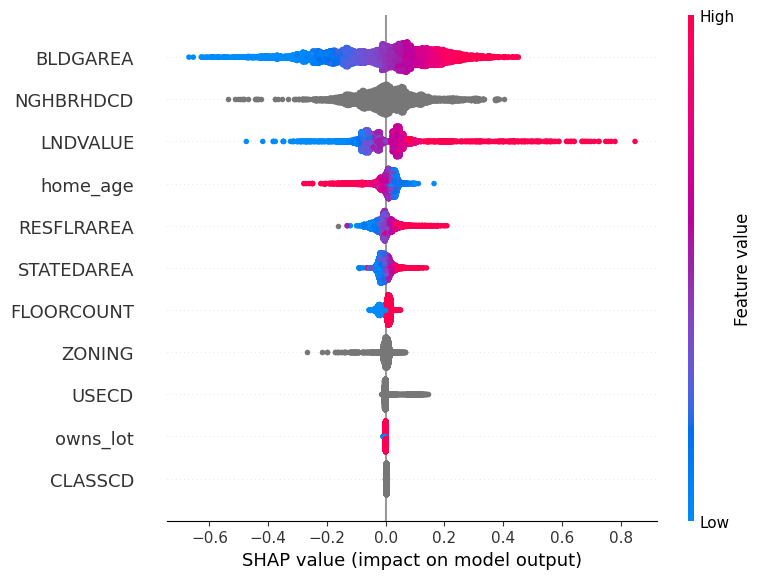

In [34]:
explainer = shap.TreeExplainer(final_model_cumming)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=True)


In [35]:
cat_features_fulton = ['LUCode', 'NbrHood']
for col in cat_features_fulton:
    alpharetta_final[col] = alpharetta_final[col].astype('category')

feature_cols_fulton = ['LandAcres', 'LivUnits'] + cat_features_fulton

X_f = alpharetta_final[feature_cols_fulton]
y_f = np.log1p(alpharetta_final['market_value'])

X_train_f, X_temp_f, y_train_f, y_temp_f = train_test_split(X_f, y_f, test_size=0.3, random_state=42)
X_valid_f, X_test_f, y_valid_f, y_test_f = train_test_split(X_temp_f, y_temp_f, test_size=0.5, random_state=42)
print(f"Train: {X_train_f.shape}, Validation: {X_valid_f.shape}, Test: {X_test_f.shape}")


Train: (13459, 4), Validation: (2884, 4), Test: (2885, 4)


In [36]:
baseline_model_f = lgb.LGBMRegressor(random_state=42, verbose=-1)
baseline_model_f.fit(X_train_f, y_train_f, categorical_feature=cat_features_fulton)

pred_log_f = baseline_model_f.predict(X_test_f)
pred_f = np.expm1(pred_log_f)
actual_f = np.expm1(y_test_f)

rmse_f = root_mean_squared_error(actual_f, pred_f)
mae_f = mean_absolute_error(actual_f, pred_f)
r2_f = r2_score(actual_f, pred_f)
print(f"Alpharetta Baseline — RMSE: ${rmse_f:,.0f}  MAE: ${mae_f:,.0f}  R2: {r2_f:.4f}")


Alpharetta Baseline — RMSE: $164,248  MAE: $76,566  R2: 0.7397


In [37]:
def objective_f(trial):
    params = {
        'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'n_estimators': 500,
    }
    model = lgb.LGBMRegressor(**params, random_state=42)
    model.fit(X_train_f, y_train_f, categorical_feature=cat_features_fulton)
    pred = model.predict(X_valid_f)  # validation, not test
    return root_mean_squared_error(y_valid_f, pred)

study_f = optuna.create_study(direction='minimize')
study_f.optimize(objective_f, n_trials=30, show_progress_bar=True)
print("Best params:", study_f.best_params)


[I 2026-07-15 00:22:25,794] A new study created in memory with name: no-name-275c695f-cdbf-4922-bddc-fb9554aa27b2


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-15 00:22:27,583] Trial 0 finished with value: 0.1920835211704836 and parameters: {'num_leaves': 149, 'learning_rate': 0.07172793782396723, 'feature_fraction': 0.7948894746599613, 'bagging_fraction': 0.6441942003117449, 'bagging_freq': 6, 'min_child_samples': 98}. Best is trial 0 with value: 0.1920835211704836.
[I 2026-07-15 00:22:29,864] Trial 1 finished with value: 0.19313291478949995 and parameters: {'num_leaves': 102, 'learning_rate': 0.03406612953097795, 'feature_fraction': 0.5383050979773919, 'bagging_fraction': 0.6409712829160348, 'bagging_freq': 7, 'min_child_samples': 74}. Best is trial 0 with value: 0.1920835211704836.
[I 2026-07-15 00:22:32,079] Trial 2 finished with value: 0.19751560642622668 and parameters: {'num_leaves': 144, 'learning_rate': 0.07227278712385775, 'feature_fraction': 0.574974233873172, 'bagging_fraction': 0.5276702316038344, 'bagging_freq': 5, 'min_child_samples': 63}. Best is trial 0 with value: 0.1920835211704836.
[I 2026-07-15 00:22:33,516] Tr

In [38]:
final_model_fulton = lgb.LGBMRegressor(**study_f.best_params, n_estimators=500, random_state=42, verbose=-1)
final_model_fulton.fit(X_train_f, y_train_f, categorical_feature=cat_features_fulton)

pred_log_f = final_model_fulton.predict(X_test_f)  # test set, never seen until now
pred_f = np.expm1(pred_log_f)
actual_f = np.expm1(y_test_f)

rmse_f = root_mean_squared_error(actual_f, pred_f)
mae_f = mean_absolute_error(actual_f, pred_f)
r2_f = r2_score(actual_f, pred_f)
mape_f = np.mean(np.abs((actual_f - pred_f) / actual_f)) * 100
print(f"Alpharetta Tuned Model — RMSE: ${rmse_f:,.0f}  MAE: ${mae_f:,.0f}  R2: {r2_f:.4f}  MAPE: {mape_f:.2f}%")


Alpharetta Tuned Model — RMSE: $162,400  MAE: $76,268  R2: 0.7456  MAPE: 10.38%


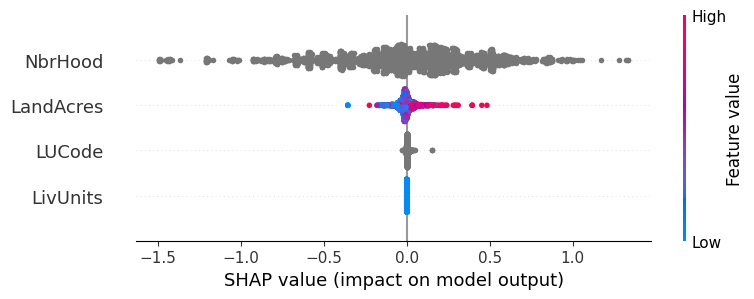

In [39]:
explainer_f = shap.TreeExplainer(final_model_fulton)
shap_values_f = explainer_f.shap_values(X_test_f)
shap.summary_plot(shap_values_f, X_test_f, show=True)


In [40]:
demo_cumming = X_test.copy()
demo_cumming['predicted_value'] = np.expm1(final_model_cumming.predict(X_test))
demo_cumming['actual_value'] = np.expm1(y_test)
demo_cumming['error'] = demo_cumming['predicted_value'] - demo_cumming['actual_value']

print(demo_cumming[['BLDGAREA', 'home_age', 'FLOORCOUNT', 'owns_lot',
                     'predicted_value', 'actual_value', 'error']].sample(10, random_state=1))


       BLDGAREA  home_age  FLOORCOUNT  owns_lot  predicted_value  \
8844     2012.0      20.0         2.0         1    497608.489961   
14205    2174.0      28.0         2.0         1    553937.458980   
29414    2462.0      35.0         1.0         1    562409.931521   
1255     1443.0      38.0         1.0         1    351511.494861   
34230    3770.0       9.0         2.0         1    850443.601770   
2264     1725.0      23.0         1.0         1    478904.881938   
43700    3073.0      20.0         2.0         1    629344.870430   
39998    3801.0       8.0         2.0         1    810444.395926   
19828    1869.0      28.0         2.0         1    404189.019643   
27962    1912.0      40.0         1.0         1    400339.309506   

       actual_value         error  
8844       499460.0  -1851.510039  
14205      585430.0 -31492.541020  
29414      491720.0  70689.931521  
1255       398810.0 -47298.505139  
34230      920130.0 -69686.398230  
2264       470960.0   7944.881938  

In [41]:
def predict_cumming_home(bldg_sqft, res_flr_area, home_age, floor_count, stated_area, land_value, owns_lot,
                          usecd='0100', nbrhoodcd=None, classcd='R3', zoning='R1'):
    input_row = pd.DataFrame([{
        'BLDGAREA': bldg_sqft, 'RESFLRAREA': res_flr_area, 'home_age': home_age,
        'FLOORCOUNT': floor_count, 'STATEDAREA': stated_area, 'LNDVALUE': land_value,
        'owns_lot': owns_lot, 'USECD': usecd,
        'NGHBRHDCD': nbrhoodcd if nbrhoodcd else cumming_final['NGHBRHDCD'].mode()[0],
        'CLASSCD': classcd, 'ZONING': zoning,
    }])
    for col in cat_features_cumming:
        input_row[col] = input_row[col].astype('category')
    pred_log = final_model_cumming.predict(input_row[feature_cols_cumming])
    return np.expm1(pred_log)[0]

# Example: 2,800 sqft detached single-family home, 15 years old, 2 floors
example_price = predict_cumming_home(
    bldg_sqft=2800, res_flr_area=1900, home_age=15, floor_count=2,
    stated_area=0.35, land_value=165000, owns_lot=1
)
print(f"Predicted value: ${example_price:,.0f}")


Predicted value: $694,706


In [42]:
demo_alpharetta = X_test_f.copy()
demo_alpharetta['predicted_value'] = np.expm1(final_model_fulton.predict(X_test_f))
demo_alpharetta['actual_value'] = np.expm1(y_test_f)
demo_alpharetta['error'] = demo_alpharetta['predicted_value'] - demo_alpharetta['actual_value']

print(demo_alpharetta[['LandAcres', 'LivUnits', 'LUCode', 'NbrHood',
                        'predicted_value', 'actual_value', 'error']].sample(10, random_state=1))


       LandAcres  LivUnits LUCode NbrHood  predicted_value  actual_value  \
17925     0.0310       1.0    107   24024    849760.486949      936500.0   
11693     0.4105       1.0    101    1181    530769.292467      627300.0   
6503      0.2464       1.0    101    2120    470285.580566      547700.0   
17321     0.0268       1.0    106    0622    225589.477288      214500.0   
12041     0.3500       1.0    101    1297    956279.773550      966500.0   
18554     0.0180       1.0    107   24028    581350.020915     1006400.0   
7499      0.2528       1.0    101    2435    557723.033214      605800.0   
19566     1.3290       1.0    101   22031    675487.854289      407200.0   
11902     0.4758       1.0    101    1225    761402.045293      734200.0   
8021      0.3464       1.0    101    2264    672592.481259      501400.0   

               error  
17925  -86739.513051  
11693  -96530.707533  
6503   -77414.419434  
17321   11089.477288  
12041  -10220.226450  
18554 -425049.979085  
74

In [43]:
def predict_alpharetta_home(land_acres, liv_units, lucode='101', nbrhood=None):
    input_row = pd.DataFrame([{
        'LandAcres': land_acres,
        'LivUnits': liv_units,
        'LUCode': lucode,
        'NbrHood': nbrhood if nbrhood else alpharetta_final['NbrHood'].mode()[0],
    }])
    for col in cat_features_fulton:
        input_row[col] = input_row[col].astype('category')
    pred_log = final_model_fulton.predict(input_row[feature_cols_fulton])
    return np.expm1(pred_log)[0]

# Example: 0.35-acre single-family lot, 1 living unit
example_price_f = predict_alpharetta_home(land_acres=0.35, liv_units=1, lucode='101')
print(f"Predicted value: ${example_price_f:,.0f}")


Predicted value: $956,280


In [44]:
lr_features_cumming = ['BLDGAREA', 'RESFLRAREA', 'home_age', 'FLOORCOUNT', 'STATEDAREA', 'LNDVALUE', 'owns_lot']

X_train_lr = X_train[lr_features_cumming].copy()
X_test_lr = X_test[lr_features_cumming].copy()

# Impute any missing values using the training mean
imputer = SimpleImputer(strategy='mean')
X_lr_cumming = pd.DataFrame(imputer.fit_transform(X_train_lr), columns=X_train_lr.columns, index=X_train_lr.index)
X_lr_test_cumming = pd.DataFrame(imputer.transform(X_test_lr), columns=X_test_lr.columns, index=X_test_lr.index)

lr_model_cumming = LinearRegression()
lr_model_cumming.fit(X_lr_cumming, y_train)

lr_pred_cumming = np.expm1(lr_model_cumming.predict(X_lr_test_cumming))
lr_actual_cumming = np.expm1(y_test)

lr_rmse_cumming = root_mean_squared_error(lr_actual_cumming, lr_pred_cumming)
lr_r2_cumming = r2_score(lr_actual_cumming, lr_pred_cumming)

print(f"Cumming Linear Regression — RMSE: ${lr_rmse_cumming:,.0f}  R2: {lr_r2_cumming:.4f}")
print()
print("Coefficients (log-value scale):")
for name, coef in zip(X_lr_cumming.columns, lr_model_cumming.coef_):
    print(f"  {name}: {coef:+.5f}")


Cumming Linear Regression — RMSE: $127,525  R2: 0.7400

Coefficients (log-value scale):
  BLDGAREA: +0.00023
  RESFLRAREA: +0.00012
  home_age: -0.00211
  FLOORCOUNT: +0.03503
  STATEDAREA: -0.00920
  LNDVALUE: +0.00000
  owns_lot: +0.09571


In [45]:
X_lr_fulton = pd.get_dummies(X_train_f, drop_first=True)
X_lr_test_fulton = pd.get_dummies(X_test_f, drop_first=True)

# Align columns in case train/test have different category levels present
X_lr_fulton, X_lr_test_fulton = X_lr_fulton.align(X_lr_test_fulton, join='left', axis=1, fill_value=0)

lr_model_fulton = LinearRegression()
lr_model_fulton.fit(X_lr_fulton, y_train_f)

lr_pred_fulton = np.expm1(lr_model_fulton.predict(X_lr_test_fulton))
lr_actual_fulton = np.expm1(y_test_f)

lr_rmse_fulton = root_mean_squared_error(lr_actual_fulton, lr_pred_fulton)
lr_r2_fulton = r2_score(lr_actual_fulton, lr_pred_fulton)

print(f"Alpharetta Linear Regression — RMSE: ${lr_rmse_fulton:,.0f}  R2: {lr_r2_fulton:.4f}")
print()
print("Top coefficients (log-value scale):")
coef_series = pd.Series(lr_model_fulton.coef_, index=X_lr_fulton.columns).sort_values(key=abs, ascending=False)
print(coef_series.head(15))


Alpharetta Linear Regression — RMSE: $151,119  R2: 0.7797

Top coefficients (log-value scale):
NbrHood_2119      2.774039
NbrHood_2024A     2.582780
NbrHood_2023D     2.526626
NbrHood_2024B     2.447589
NbrHood_2023C     2.193808
NbrHood_2021F     2.191304
NbrHood_0222A     2.172602
NbrHood_21022W    2.165156
NbrHood_2183      2.154104
NbrHood_2021K     2.127518
NbrHood_3345H     2.105964
NbrHood_2023A     2.068958
NbrHood_24025     2.005778
NbrHood_21249     1.978379
NbrHood_22302     1.956123
dtype: float64


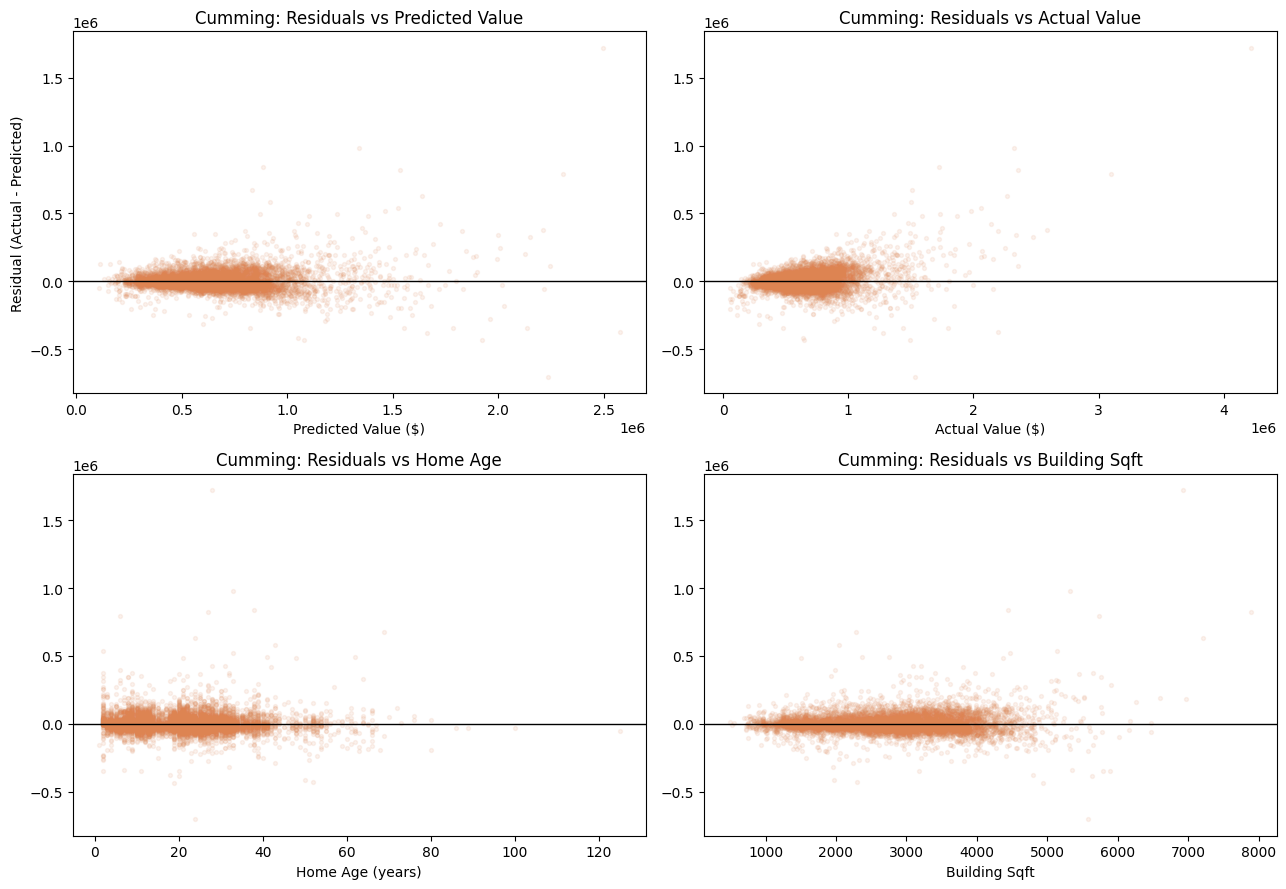

In [46]:
residuals_cumming = actual - pred

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].scatter(pred, residuals_cumming, alpha=0.1, s=8, color='#DD8452')
axes[0,0].axhline(0, color='black', linewidth=1)
axes[0,0].set_title('Cumming: Residuals vs Predicted Value')
axes[0,0].set_xlabel('Predicted Value ($)')
axes[0,0].set_ylabel('Residual (Actual - Predicted)')

axes[0,1].scatter(actual, residuals_cumming, alpha=0.1, s=8, color='#DD8452')
axes[0,1].axhline(0, color='black', linewidth=1)
axes[0,1].set_title('Cumming: Residuals vs Actual Value')
axes[0,1].set_xlabel('Actual Value ($)')

axes[1,0].scatter(X_test['home_age'], residuals_cumming, alpha=0.1, s=8, color='#DD8452')
axes[1,0].axhline(0, color='black', linewidth=1)
axes[1,0].set_title('Cumming: Residuals vs Home Age')
axes[1,0].set_xlabel('Home Age (years)')

axes[1,1].scatter(X_test['BLDGAREA'], residuals_cumming, alpha=0.1, s=8, color='#DD8452')
axes[1,1].axhline(0, color='black', linewidth=1)
axes[1,1].set_title('Cumming: Residuals vs Building Sqft')
axes[1,1].set_xlabel('Building Sqft')

plt.tight_layout()
plt.show()


In [47]:
resid_df_cumming = X_test.copy()
resid_df_cumming['residual'] = residuals_cumming
resid_df_cumming['abs_pct_error'] = (residuals_cumming.abs() / actual) * 100
resid_df_cumming['value_tier'] = pd.qcut(actual, 5, labels=['Lowest 20%', '20-40%', '40-60%', '60-80%', 'Top 20%'])

print("Mean absolute % error by value tier:")
print(resid_df_cumming.groupby('value_tier', observed=True)['abs_pct_error'].mean())
print()
print("Mean absolute % error by property type (USECD):")
print(resid_df_cumming.groupby('USECD', observed=True)['abs_pct_error'].mean().sort_values(ascending=False))


Mean absolute % error by value tier:
value_tier
Lowest 20%    7.746343
20-40%        5.059514
40-60%        5.444273
60-80%        6.098694
Top 20%       7.725240
Name: abs_pct_error, dtype: float64

Mean absolute % error by property type (USECD):
USECD
0122    12.362127
0124    10.376902
0123     9.196780
0101     8.093333
0100     6.507394
0127     6.006626
0309     2.990407
0300     2.989253
0113     2.651428
Name: abs_pct_error, dtype: float64


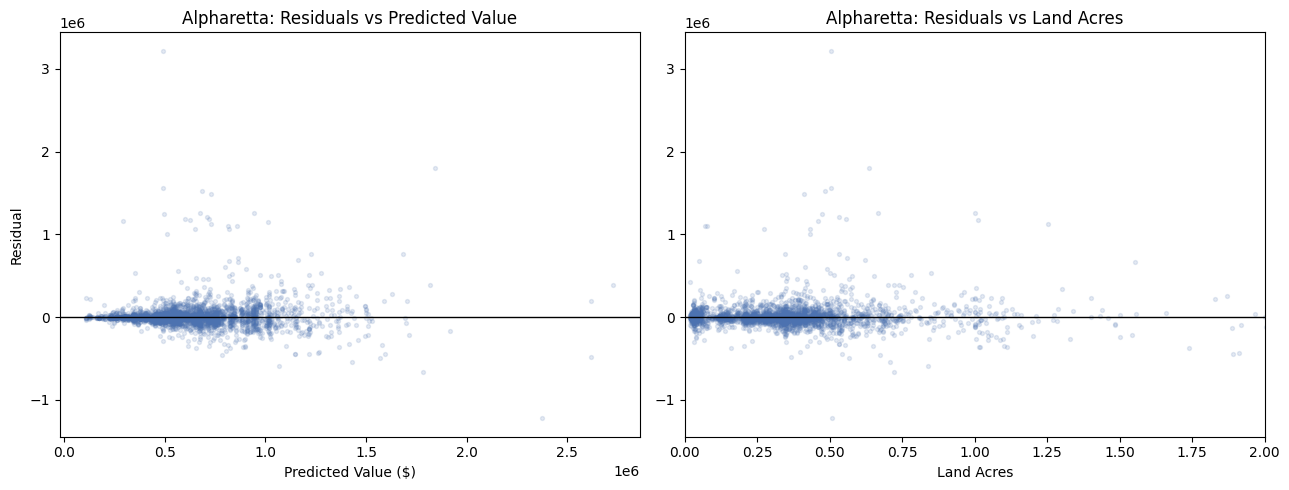

Mean absolute % error by value tier:
value_tier
Lowest 20%     9.340430
20-40%        10.112708
40-60%         8.799044
60-80%         9.911561
Top 20%       13.749924
Name: abs_pct_error, dtype: float64

Mean absolute % error by property type (LUCode):
LUCode
101    11.805360
106     4.553450
107     6.348391
Name: abs_pct_error, dtype: float64


In [48]:
residuals_fulton = actual_f - pred_f

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(pred_f, residuals_fulton, alpha=0.15, s=8, color='#4C72B0')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Alpharetta: Residuals vs Predicted Value')
axes[0].set_xlabel('Predicted Value ($)')
axes[0].set_ylabel('Residual')

axes[1].scatter(X_test_f['LandAcres'], residuals_fulton, alpha=0.15, s=8, color='#4C72B0')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Alpharetta: Residuals vs Land Acres')
axes[1].set_xlabel('Land Acres')
axes[1].set_xlim(0, 2)

plt.tight_layout()
plt.show()

resid_df_fulton = X_test_f.copy()
resid_df_fulton['residual'] = residuals_fulton
resid_df_fulton['abs_pct_error'] = (residuals_fulton.abs() / actual_f) * 100
resid_df_fulton['value_tier'] = pd.qcut(actual_f, 5, labels=['Lowest 20%', '20-40%', '40-60%', '60-80%', 'Top 20%'])

print("Mean absolute % error by value tier:")
print(resid_df_fulton.groupby('value_tier', observed=True)['abs_pct_error'].mean())
print()
print("Mean absolute % error by property type (LUCode):")
print(resid_df_fulton.groupby('LUCode', observed=True)['abs_pct_error'].mean())


In [49]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_cumming, cv_mae_cumming, cv_r2_cumming = [], [], []

X_full_cumming = pd.concat([X_train, X_valid, X_test])
y_full_cumming = pd.concat([y_train, y_valid, y_test])

for fold, (train_idx, test_idx) in enumerate(kf.split(X_full_cumming)):
    X_tr, X_te = X_full_cumming.iloc[train_idx], X_full_cumming.iloc[test_idx]
    y_tr, y_te = y_full_cumming.iloc[train_idx], y_full_cumming.iloc[test_idx]

    model = lgb.LGBMRegressor(**study.best_params, n_estimators=500, random_state=42, verbose=-1)
    model.fit(X_tr, y_tr, categorical_feature=cat_features_cumming)

    fold_pred = np.expm1(model.predict(X_te))
    fold_actual = np.expm1(y_te)

    cv_rmse_cumming.append(root_mean_squared_error(fold_actual, fold_pred))
    cv_mae_cumming.append(mean_absolute_error(fold_actual, fold_pred))
    cv_r2_cumming.append(r2_score(fold_actual, fold_pred))
    print(f"Fold {fold+1}: RMSE=${cv_rmse_cumming[-1]:,.0f}  MAE=${cv_mae_cumming[-1]:,.0f}  R2={cv_r2_cumming[-1]:.4f}")

print()
print(f"Cumming CV — RMSE: ${np.mean(cv_rmse_cumming):,.0f} \u00b1 ${np.std(cv_rmse_cumming):,.0f}")
print(f"Cumming CV — MAE:  ${np.mean(cv_mae_cumming):,.0f} \u00b1 ${np.std(cv_mae_cumming):,.0f}")
print(f"Cumming CV — R2:   {np.mean(cv_r2_cumming):.4f} \u00b1 {np.std(cv_r2_cumming):.4f}")


Fold 1: RMSE=$66,646  MAE=$41,682  R2=0.9283
Fold 2: RMSE=$66,185  MAE=$41,196  R2=0.9267
Fold 3: RMSE=$63,685  MAE=$40,400  R2=0.9308
Fold 4: RMSE=$83,051  MAE=$41,936  R2=0.8959
Fold 5: RMSE=$69,764  MAE=$41,129  R2=0.9226

Cumming CV — RMSE: $69,866 ± $6,870
Cumming CV — MAE:  $41,269 ± $528
Cumming CV — R2:   0.9209 ± 0.0128


In [50]:
cv_rmse_fulton, cv_mae_fulton, cv_r2_fulton = [], [], []

X_full_fulton = pd.concat([X_train_f, X_valid_f, X_test_f])
y_full_fulton = pd.concat([y_train_f, y_valid_f, y_test_f])

for fold, (train_idx, test_idx) in enumerate(kf.split(X_full_fulton)):
    X_tr, X_te = X_full_fulton.iloc[train_idx], X_full_fulton.iloc[test_idx]
    y_tr, y_te = y_full_fulton.iloc[train_idx], y_full_fulton.iloc[test_idx]

    model = lgb.LGBMRegressor(**study_f.best_params, n_estimators=500, random_state=42, verbose=-1)
    model.fit(X_tr, y_tr, categorical_feature=cat_features_fulton)

    fold_pred = np.expm1(model.predict(X_te))
    fold_actual = np.expm1(y_te)

    cv_rmse_fulton.append(root_mean_squared_error(fold_actual, fold_pred))
    cv_mae_fulton.append(mean_absolute_error(fold_actual, fold_pred))
    cv_r2_fulton.append(r2_score(fold_actual, fold_pred))
    print(f"Fold {fold+1}: RMSE=${cv_rmse_fulton[-1]:,.0f}  MAE=${cv_mae_fulton[-1]:,.0f}  R2={cv_r2_fulton[-1]:.4f}")

print()
print(f"Alpharetta CV — RMSE: ${np.mean(cv_rmse_fulton):,.0f} \u00b1 ${np.std(cv_rmse_fulton):,.0f}")
print(f"Alpharetta CV — MAE:  ${np.mean(cv_mae_fulton):,.0f} \u00b1 ${np.std(cv_mae_fulton):,.0f}")
print(f"Alpharetta CV — R2:   {np.mean(cv_r2_fulton):.4f} \u00b1 {np.std(cv_r2_fulton):.4f}")


Fold 1: RMSE=$133,808  MAE=$72,432  R2=0.8167
Fold 2: RMSE=$166,934  MAE=$77,827  R2=0.7429
Fold 3: RMSE=$195,016  MAE=$79,543  R2=0.6622
Fold 4: RMSE=$142,159  MAE=$71,019  R2=0.7947
Fold 5: RMSE=$164,476  MAE=$74,183  R2=0.7455

Alpharetta CV — RMSE: $160,479 ± $21,435
Alpharetta CV — MAE:  $75,001 ± $3,217
Alpharetta CV — R2:   0.7524 ± 0.0533


In [51]:
def train_quantile_model(X_tr, y_tr, alpha, cat_features):
    model = lgb.LGBMRegressor(objective='quantile', alpha=alpha, n_estimators=500,
                               num_leaves=study.best_params['num_leaves'],
                               learning_rate=study.best_params['learning_rate'],
                               random_state=42, verbose=-1)
    model.fit(X_tr, y_tr, categorical_feature=cat_features)
    return model

lower_model_cumming = train_quantile_model(X_train, y_train, alpha=0.1, cat_features=cat_features_cumming)
upper_model_cumming = train_quantile_model(X_train, y_train, alpha=0.9, cat_features=cat_features_cumming)

lower_pred = np.expm1(lower_model_cumming.predict(X_test))
upper_pred = np.expm1(upper_model_cumming.predict(X_test))

coverage = ((actual >= lower_pred) & (actual <= upper_pred)).mean()
print(f"80% prediction interval coverage (should be close to 0.80): {coverage:.3f}")


80% prediction interval coverage (should be close to 0.80): 0.730


In [52]:
def predict_cumming_home_range(bldg_sqft, res_flr_area, home_age, floor_count, stated_area, land_value, owns_lot,
                                usecd='0100', nbrhoodcd=None, classcd='R3', zoning='R1'):
    input_row = pd.DataFrame([{
        'BLDGAREA': bldg_sqft, 'RESFLRAREA': res_flr_area, 'home_age': home_age,
        'FLOORCOUNT': floor_count, 'STATEDAREA': stated_area, 'LNDVALUE': land_value,
        'owns_lot': owns_lot, 'USECD': usecd,
        'NGHBRHDCD': nbrhoodcd if nbrhoodcd else cumming_final['NGHBRHDCD'].mode()[0],
        'CLASSCD': classcd, 'ZONING': zoning,
    }])
    for col in cat_features_cumming:
        input_row[col] = input_row[col].astype('category')
    input_row = input_row[feature_cols_cumming]

    point = np.expm1(final_model_cumming.predict(input_row))[0]
    low = np.expm1(lower_model_cumming.predict(input_row))[0]
    high = np.expm1(upper_model_cumming.predict(input_row))[0]
    return point, low, high

point, low, high = predict_cumming_home_range(
    bldg_sqft=2800, res_flr_area=1900, home_age=15, floor_count=2,
    stated_area=0.35, land_value=165000, owns_lot=1
)
print(f"Predicted value: ${point:,.0f}  (likely range: ${low:,.0f} \u2013 ${high:,.0f})")


Predicted value: $694,706  (likely range: $640,698 – $877,727)


In [53]:
def train_quantile_model_f(X_tr, y_tr, alpha, cat_features):
    model = lgb.LGBMRegressor(objective='quantile', alpha=alpha, n_estimators=500,
                               num_leaves=study_f.best_params['num_leaves'],
                               learning_rate=study_f.best_params['learning_rate'],
                               random_state=42, verbose=-1)
    model.fit(X_tr, y_tr, categorical_feature=cat_features)
    return model

lower_model_fulton = train_quantile_model_f(X_train_f, y_train_f, alpha=0.1, cat_features=cat_features_fulton)
upper_model_fulton = train_quantile_model_f(X_train_f, y_train_f, alpha=0.9, cat_features=cat_features_fulton)

lower_pred_f = np.expm1(lower_model_fulton.predict(X_test_f))
upper_pred_f = np.expm1(upper_model_fulton.predict(X_test_f))

coverage_f = ((actual_f >= lower_pred_f) & (actual_f <= upper_pred_f)).mean()
print(f"80% prediction interval coverage (should be close to 0.80): {coverage_f:.3f}")


80% prediction interval coverage (should be close to 0.80): 0.801


In [54]:
final_model_cumming_full = lgb.LGBMRegressor(**study.best_params, n_estimators=500, random_state=42, verbose=-1)
final_model_cumming_full.fit(X_full_cumming, y_full_cumming, categorical_feature=cat_features_cumming)

final_model_fulton_full = lgb.LGBMRegressor(**study_f.best_params, n_estimators=500, random_state=42, verbose=-1)
final_model_fulton_full.fit(X_full_fulton, y_full_fulton, categorical_feature=cat_features_fulton)

lower_model_cumming_full = train_quantile_model(X_full_cumming, y_full_cumming, alpha=0.1, cat_features=cat_features_cumming)
upper_model_cumming_full = train_quantile_model(X_full_cumming, y_full_cumming, alpha=0.9, cat_features=cat_features_cumming)
lower_model_fulton_full = train_quantile_model_f(X_full_fulton, y_full_fulton, alpha=0.1, cat_features=cat_features_fulton)
upper_model_fulton_full = train_quantile_model_f(X_full_fulton, y_full_fulton, alpha=0.9, cat_features=cat_features_fulton)

joblib.dump(final_model_cumming_full, f'{save_dir}/model_cumming_point.pkl')
joblib.dump(lower_model_cumming_full, f'{save_dir}/model_cumming_lower.pkl')
joblib.dump(upper_model_cumming_full, f'{save_dir}/model_cumming_upper.pkl')
joblib.dump(final_model_fulton_full, f'{save_dir}/model_fulton_point.pkl')
joblib.dump(lower_model_fulton_full, f'{save_dir}/model_fulton_lower.pkl')
joblib.dump(upper_model_fulton_full, f'{save_dir}/model_fulton_upper.pkl')

print("All models saved to", save_dir)


All models saved to data


In [55]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_dir = '/content/drive/MyDrive/housing_price_project'
os.makedirs(save_dir, exist_ok=True)

Mounted at /content/drive


In [56]:
print("Current save_dir value:", save_dir)

Current save_dir value: /content/drive/MyDrive/housing_price_project


In [57]:
import os

print("--- Local Colab storage (resets on disconnect) ---")
if os.path.exists('data'):
    print(os.listdir('data'))
else:
    print("no local 'data' folder found")

print()
print("--- Google Drive folder ---")
drive_path = '/content/drive/MyDrive/housing_price_project'
if os.path.exists(drive_path):
    print(os.listdir(drive_path))
else:
    print("Drive folder not found at that path")

--- Local Colab storage (resets on disconnect) ---
['alpharetta_clean.csv', 'model_cumming_point.pkl', 'cumming_clean.csv', 'model_cumming_upper.pkl', 'model_fulton_lower.pkl', 'model_fulton_upper.pkl', 'model_fulton_point.pkl', 'model_cumming_lower.pkl']

--- Google Drive folder ---
[]


In [58]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_dir = '/content/drive/MyDrive/housing_price_project'
os.makedirs(save_dir, exist_ok=True)
print("save_dir is now:", save_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
save_dir is now: /content/drive/MyDrive/housing_price_project


In [59]:
import json
import numpy as np

# --- Cell A: export prediction-enriched datasets ---
cumming_export = cumming_final.copy()
cumming_export['predicted_value'] = np.expm1(final_model_cumming_full.predict(X_full_cumming))
cumming_export['pred_low'] = np.expm1(lower_model_cumming_full.predict(X_full_cumming))
cumming_export['pred_high'] = np.expm1(upper_model_cumming_full.predict(X_full_cumming))
cumming_export.to_csv(f'{save_dir}/cumming_export.csv', index=False)

alpharetta_export = alpharetta_final.copy()
alpharetta_export['predicted_value'] = np.expm1(final_model_fulton_full.predict(X_full_fulton))
alpharetta_export['pred_low'] = np.expm1(lower_model_fulton_full.predict(X_full_fulton))
alpharetta_export['pred_high'] = np.expm1(upper_model_fulton_full.predict(X_full_fulton))
alpharetta_export.to_csv(f'{save_dir}/alpharetta_export.csv', index=False)
print("Cell A done: CSVs exported")

# --- Cell B: dump trees to JSON for browser-side scoring ---
with open(f'{save_dir}/model_cumming_point.json', 'w') as f:
    json.dump(final_model_cumming_full.booster_.dump_model(), f)
with open(f'{save_dir}/model_cumming_lower.json', 'w') as f:
    json.dump(lower_model_cumming_full.booster_.dump_model(), f)
with open(f'{save_dir}/model_cumming_upper.json', 'w') as f:
    json.dump(upper_model_cumming_full.booster_.dump_model(), f)
with open(f'{save_dir}/model_fulton_point.json', 'w') as f:
    json.dump(final_model_fulton_full.booster_.dump_model(), f)
with open(f'{save_dir}/model_fulton_lower.json', 'w') as f:
    json.dump(lower_model_fulton_full.booster_.dump_model(), f)
with open(f'{save_dir}/model_fulton_upper.json', 'w') as f:
    json.dump(upper_model_fulton_full.booster_.dump_model(), f)
print("Cell B done: model trees dumped to JSON")

# --- Cell C: precompute SHAP values for every home ---
shap_cumming = explainer.shap_values(X_full_cumming)
np.save(f'{save_dir}/shap_cumming.npy', shap_cumming)
shap_fulton = explainer_f.shap_values(X_full_fulton)
np.save(f'{save_dir}/shap_fulton.npy', shap_fulton)
print("Cell C done: SHAP values exported")

print()
print("All files in", save_dir, ":")
print(os.listdir(save_dir))

Cell A done: CSVs exported
Cell B done: model trees dumped to JSON
Cell C done: SHAP values exported

All files in /content/drive/MyDrive/housing_price_project :
['cumming_export.csv', 'alpharetta_export.csv', 'model_cumming_point.json', 'model_cumming_lower.json', 'model_cumming_upper.json', 'model_fulton_point.json', 'model_fulton_lower.json', 'model_fulton_upper.json', 'shap_cumming.npy', 'shap_fulton.npy']
